## 1. Data Exploration

In [31]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.dummy import DummyClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [2]:
# Load the data
# For Google Colab:
#from google.colab import drive
#drive.mount('/content/drive')
#df = pd.read_csv('/content/drive/MyDrive/Datasets/Diabetes/diabetic_data.csv')

df = pd.read_csv('diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
# Quick overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

---
## 2. Data Cleaning

In [4]:
# Create a clean copy and drop specified columns
df_clean = df.copy()

# Columns to drop as per requirements
cols_to_drop = [
    'weight',           # 97% missing
    'max_glu_serum',    # 83% missing
    'A1Cresult',        # 95% missing
    'encounter_id',     # ID column, not useful for prediction
    'patient_nbr',      # ID column, not useful for prediction
]

In [5]:
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns, {df_clean.shape[1]} remaining")

Dropped 5 columns, 45 remaining


In [6]:
# Fill '?' with 'Missing' for medical_specialty and payer_code instead of dropping
for col in ['medical_specialty', 'payer_code']:
    df_clean[col] = df_clean[col].replace('?', 'Missing')

In [7]:
#Handle '?' in diagnosis
for col in ['diag_1','diag_2','diag_3']:
    df_clean[col] = df_clean[col].replace('?', np.nan)

In [8]:
# Handle Death/Hospice Leakage
# Patients who died or were discharged to hospice cannot be readmitted — keeping them
# would leak the outcome (guaranteed non-readmission) into the training data.
death_hospice_ids = [11, 13, 14, 19, 20, 21]
before = len(df_clean)
df_clean = df_clean[~df_clean['discharge_disposition_id'].isin(death_hospice_ids)]

In [9]:
# Remove invalid gender rows as there are only 3
df_clean = df_clean[df_clean['gender'] != 'Unknown/Invalid']

# Reclassify 'Race' which is '?' into 'Other'
df_clean['race'] = df_clean['race'].replace('?', 'Other')
print(df_clean['race'].value_counts())

race
Caucasian          74220
AfricanAmerican    18772
Other               3703
Hispanic            2017
Asian                628
Name: count, dtype: int64


In [10]:
# Convert admission_type_id to binary: emergency vs non-emergency
# Codes: 1:Emergency, 2:Urgent - emergency; 3:Elective, 4+ = Other, non-emergency
df_clean['emergency_admission'] = df_clean['admission_type_id'].isin([1, 2]).astype(int)

print(f"  Emergency (types 1,2): {df_clean['emergency_admission'].sum():,} ({df_clean['emergency_admission'].mean()*100:.1f}%)")
print(f"  Non-emergency:         {(1 - df_clean['emergency_admission']).sum():,} ({(1-df_clean['emergency_admission'].mean())*100:.1f}%)")

# Convert admission_source_id to binary: emergency vs non-emergency
# Code 7: Emergency Room; all others: non-emergency source
df_clean['emergency_source'] = (df_clean['admission_source_id'] == 7).astype(int)
print(f"  ER source (code 7):    {df_clean['emergency_source'].sum():,} ({df_clean['emergency_source'].mean()*100:.1f}%)")
print(f"  Non-ER source:         {(1 - df_clean['emergency_source']).sum():,} ({(1-df_clean['emergency_source'].mean())*100:.1f}%)")

# Drop the original ID columns since we have extracted the binary features
df_clean = df_clean.drop(columns=['admission_type_id', 'admission_source_id'])

  Emergency (types 1,2): 70,501 (71.0%)
  Non-emergency:         28,839 (29.0%)
  ER source (code 7):    55,848 (56.2%)
  Non-ER source:         43,492 (43.8%)


---
## 3. Feature Engineering

### 3.1 Target Variable

In [11]:
# Create binary target: 1 = Readmitted (any time), 0 = Not readmitted
df_clean['readmitted_binary'] = df_clean['readmitted'].apply(
    lambda x: 0 if x == 'NO' else 1
)

target_dist = df_clean['readmitted_binary'].value_counts()
print(f"Not Readmitted (0): {target_dist[0]:,} ({target_dist[0]/len(df_clean)*100:.1f}%)")
print(f"Readmitted (1):     {target_dist[1]:,} ({target_dist[1]/len(df_clean)*100:.1f}%)")

df_clean = df_clean.drop(columns=['readmitted'])

Not Readmitted (0): 52,524 (52.9%)
Readmitted (1):     46,816 (47.1%)


### 3.2 ICD-9 Diagnosis Code Mapping

In [12]:
#Map the values in the diagnosis columns with their appropriate diagnosis. Diagnosis codes are referenced from ICD-9
def map_icd9_to_category(code):
    if str(code) == '?' or pd.isna(code): return 'Other'
    code_str = str(code)
    if code_str.startswith('V') or code_str.startswith('E'): return 'Other'
    try: code_num = float(code_str)
    except ValueError: return 'Other'
    val = int(code_num)
    if val == 250: return 'Diabetes'
    elif (val >= 390 and val <= 459) or val == 785: return 'Circulatory'
    elif (val >= 460 and val <= 519) or val == 786: return 'Respiratory'
    elif (val >= 520 and val <= 579) or val == 787: return 'Digestive'
    elif (val >= 800 and val <= 999): return 'Injury'
    elif (val >= 710 and val <= 739): return 'Musculoskeletal'
    elif (val >= 580 and val <= 629) or val == 788: return 'Genitourinary'
    elif (val >= 140 and val <= 239): return 'Neoplasms'
    else: return 'Other'

if 'diag_1' in df_clean.columns and 'diag_2' in df_clean.columns and 'diag_3' in df_clean.columns:
    for col in ['diag_1','diag_2','diag_3']:
        df_clean[f'{col}_group'] = df_clean[col].apply(map_icd9_to_category).astype('category')

    # Drop the original raw ICD-9 code columns (keep the grouped categories)
    df_clean = df_clean.drop(columns=['diag_1','diag_2','diag_3'])
    print(f"  diag_1 categories: {df_clean['diag_1_group'].cat.categories.tolist()}")

  diag_1 categories: ['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'Other', 'Respiratory']


### 3.3 Encode Categorical Variables

In [13]:
# Keep categorical columns as pandas 'category' dtype as LightGBM can use them. LogReg/ Random Forest have to dummy later

# Convert Gender, Race to category
df_clean['gender'] = df_clean['gender'].astype('category')

df_clean['race'] = df_clean['race'].astype('category')

In [14]:
# Convert age ranges to midpoints so they can be used as numerics
age_mapping = {'[0-10)':5,'[10-20)':15,'[20-30)':25,'[30-40)':35,'[40-50)':45,
               '[50-60)':55,'[60-70)':65,'[70-80)':75,'[80-90)':85,'[90-100)':95}
df_clean['age'] = df_clean['age'].map(age_mapping)

In [15]:
# Map change and diabetes med to 1,0
df_clean['change'] = df_clean['change'].map({'No':0,'Ch':1})
df_clean['diabetesMed'] = df_clean['diabetesMed'].map({'No':0,'Yes':1})

In [16]:
# Convert medical_specialty to categorical features based on their codes
def group_specialty(spec):
    spec_lower = str(spec).lower()
    if 'surgery' in spec_lower: return 'Surgery'
    if 'internalmedicine' in spec_lower or 'family' in spec_lower or 'general' in spec_lower: return 'General_Medicine'
    if 'cardiology' in spec_lower: return 'Cardiology'
    if 'emergency' in spec_lower: return 'Emergency'
    if 'nephrology' in spec_lower or 'orthopedics' in spec_lower or 'radiologist' in spec_lower: return 'Specialist'
    return 'Other'

df_clean['medical_specialty'] = df_clean['medical_specialty'].apply(group_specialty).astype('category')
print(df_clean['medical_specialty'].value_counts())

medical_specialty
Other               54899
General_Medicine    21489
Emergency            7422
Cardiology           5285
Specialist           5282
Surgery              4963
Name: count, dtype: int64


In [17]:
# Payer code → group into top 5 paying codes for socio economic grouping
top_payers = df_clean['payer_code'].value_counts().nlargest(5).index.tolist()
df_clean['payer_code'] = df_clean['payer_code'].where(
    df_clean['payer_code'].isin(top_payers), 'Other'
).astype('category')
print(df_clean['payer_code'].value_counts())

payer_code
Missing    39397
MC         31333
Other      12873
HM          6195
SP          4941
BC          4601
Name: count, dtype: int64


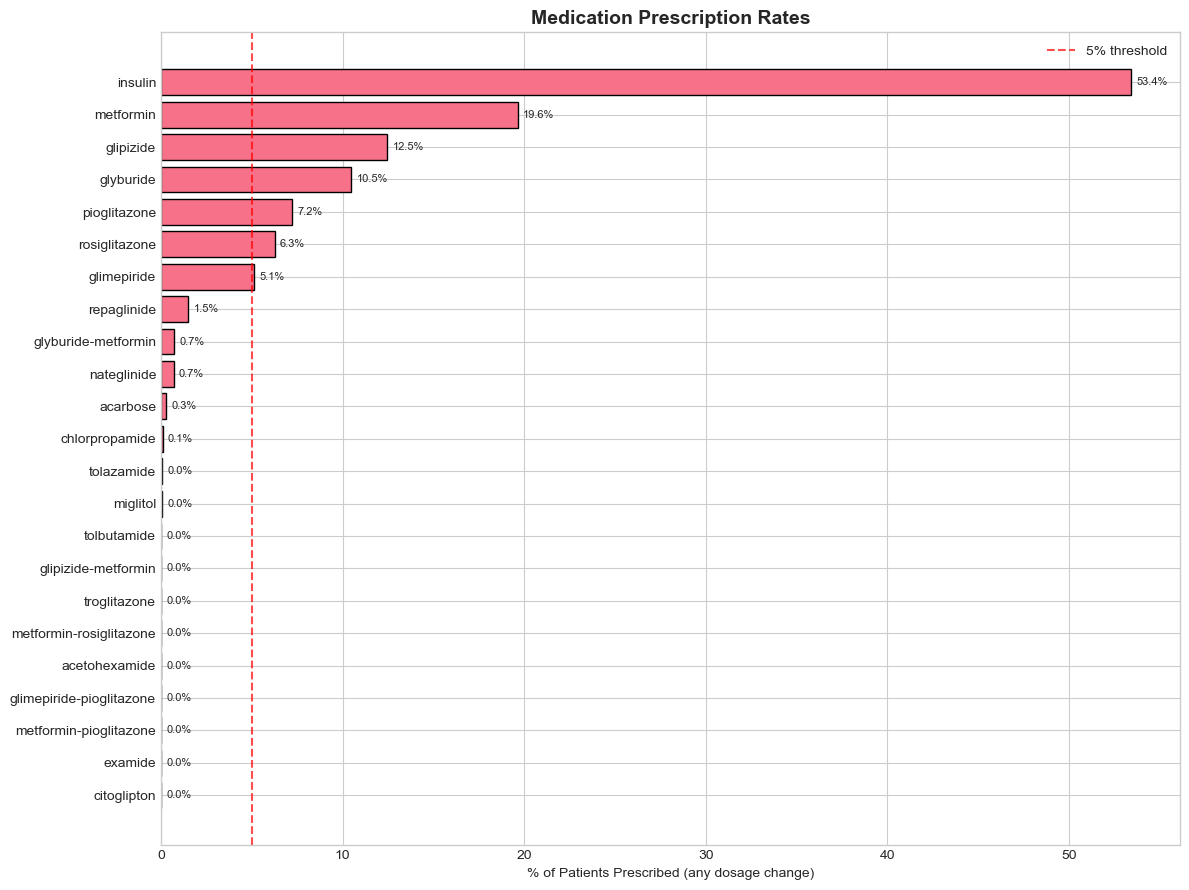

In [18]:
# Medication Column Investigation
# The raw dataset has 23 medication columns. Each contains values: No, Steady, Down, Up.
# We can visualise how often these were administered to decide which to choose
med_cols_original = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
    'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone','rosiglitazone',
    'acarbose','miglitol','troglitazone','tolazamide','examide','citoglipton','insulin',
    'glyburide-metformin','glipizide-metformin','glimepiride-pioglitazone',
    'metformin-rosiglitazone','metformin-pioglitazone']

med_summary = []
for col in med_cols_original:
    vc = df[col].value_counts()
    no_pct = vc.get('No', 0) / len(df) * 100  #Count how many patients are not taking the medication and *100 to get percent
    prescribed_pct = 100 - no_pct  #Get a percent of how many patients do not take
    med_summary.append({'medication': col, 'prescribed_pct': prescribed_pct, 'no_pct': no_pct,
                        'steady': vc.get('Steady', 0), 'up': vc.get('Up', 0), 'down': vc.get('Down', 0)})

med_df = pd.DataFrame(med_summary).sort_values('prescribed_pct', ascending=True)
#visualise the percentage of patients taking each medication
fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(med_df['medication'], med_df['prescribed_pct'], edgecolor='black')
ax.set_xlabel('% of Patients Prescribed (any dosage change)')
ax.set_title('Medication Prescription Rates', fontsize=14, fontweight='bold')
ax.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='5% threshold')
ax.legend()

for i, (_, row) in enumerate(med_df.iterrows()):
    ax.text(row['prescribed_pct']+0.3, i, f"{row['prescribed_pct']:.1f}%", va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [19]:
# Medication Feature Engineering
# Only keep the medication with > 5% prescription rate as anything less would risk being overemphasised by the model
keep_meds = [
    'insulin', 'metformin', 'glipizide', 'glyburide',
    'pioglitazone', 'rosiglitazone', 'glimepiride'
]

drop_meds = [
    'repaglinide', 'nateglinide', 'chlorpropamide', 'acetohexamide',
    'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

# Convert kept medications to category dtype
for col in keep_meds:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

# Drop those which have around 2% or less prescription
existing_drop = [c for c in drop_meds if c in df_clean.columns]
df_clean = df_clean.drop(columns=existing_drop)

print(f"Kept medications as categories: {keep_meds}")
print(f"Dropped {len(existing_drop)} near-zero-variance medication columns")
print(f"Dataset shape: {df_clean.shape}")

Kept medications as categories: ['insulin', 'metformin', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'glimepiride']
Dropped 16 near-zero-variance medication columns
Dataset shape: (99340, 29)


In [20]:
# Final dataset overview
cat_cols = df_clean.select_dtypes(include='category').columns.tolist()
num_cols = df_clean.select_dtypes(include='number').columns.tolist()

print(f"Final Dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns ({len(num_cols)}): {num_cols}")

Final Dataset: 99,340 rows × 29 columns

Categorical columns (14): ['race', 'gender', 'payer_code', 'medical_specialty', 'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'diag_1_group', 'diag_2_group', 'diag_3_group']
Numeric columns (15): ['age', 'discharge_disposition_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'change', 'diabetesMed', 'emergency_admission', 'emergency_source', 'readmitted_binary']


---
## 4. Exploratory Data Analysis (EDA)

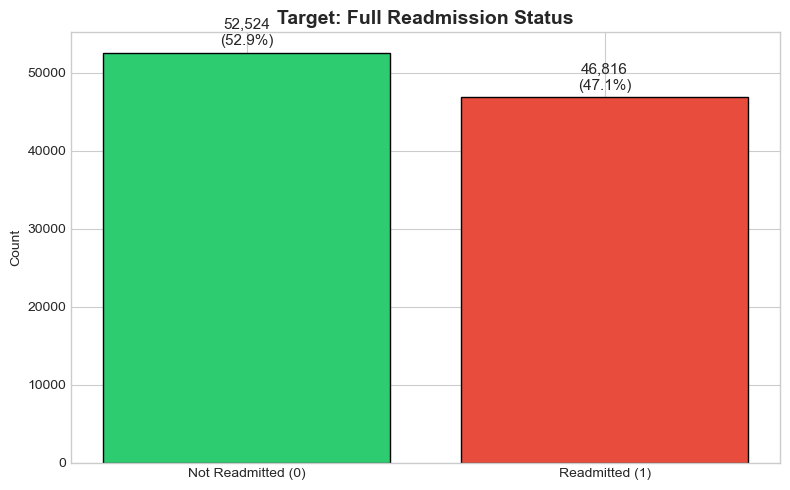

In [21]:
# 4.1 Target variable
fig, ax = plt.subplots(figsize=(8, 5))
colors_binary = ['#2ecc71', '#e74c3c']
target_counts = df_clean['readmitted_binary'].value_counts().sort_index()
bars = ax.bar(['Not Readmitted (0)', 'Readmitted (1)'], target_counts.values, color=colors_binary, edgecolor='black')
ax.set_title('Target: Full Readmission Status', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
for bar, count in zip(bars, target_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000, f'{count:,}\n({count/len(df_clean)*100:.1f}%)', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

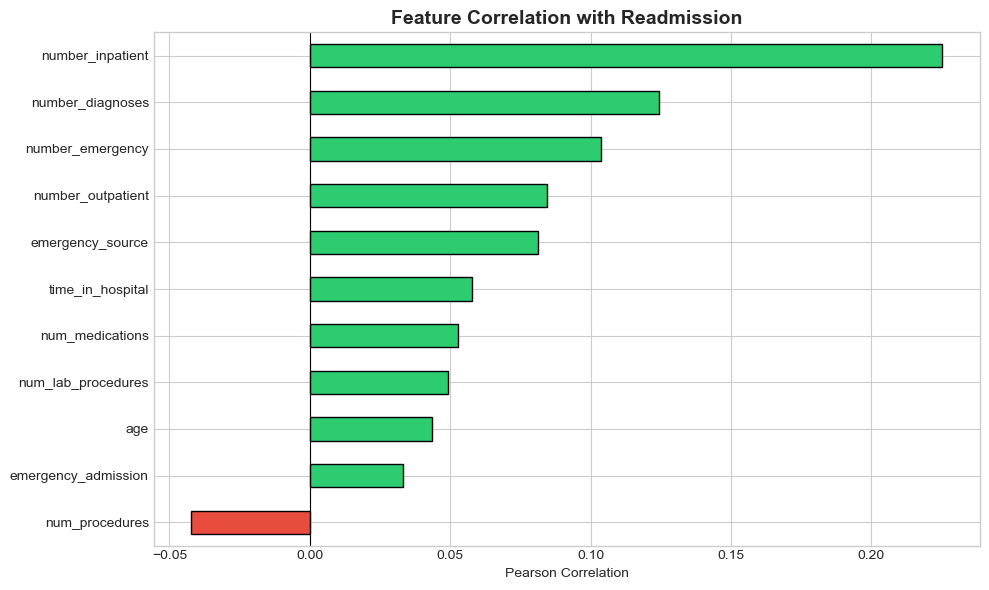

In [22]:
# 4.2 Correlation with target
numerical_cols = ['time_in_hospital','num_lab_procedures','num_procedures','num_medications',
                  'number_outpatient','number_emergency','number_inpatient','number_diagnoses',
                  'age','emergency_admission','emergency_source']
correlations = df_clean[numerical_cols + ['readmitted_binary']].corr()['readmitted_binary'].drop('readmitted_binary').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in correlations.values]
correlations.plot(kind='barh', color=colors, edgecolor='black', ax=ax)
ax.set_title('Feature Correlation with Readmission', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

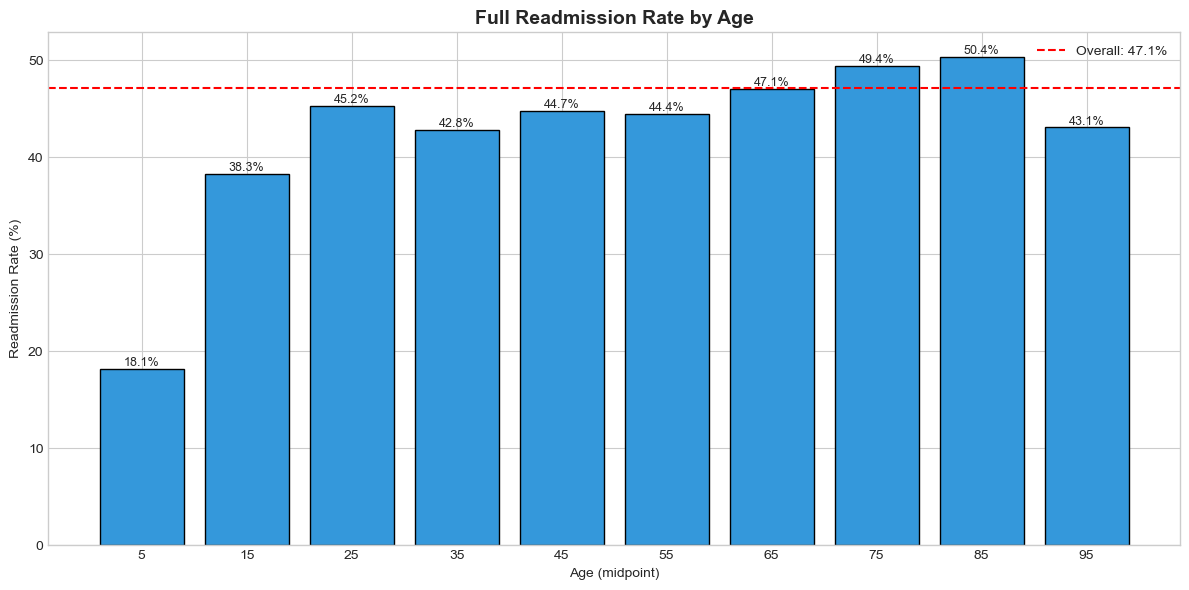

In [23]:
# 4.3 Readmission by Age
age_readmit = df_clean.groupby('age')['readmitted_binary'].mean() * 100
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(age_readmit.index.astype(str), age_readmit.values, color='#3498db', edgecolor='black')
ax.set_title('Full Readmission Rate by Age', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (midpoint)'); ax.set_ylabel('Readmission Rate (%)')
ax.axhline(y=df_clean['readmitted_binary'].mean()*100, color='red', linestyle='--', #Create a red line representing the average readmission rate
           label=f'Overall: {df_clean["readmitted_binary"].mean()*100:.1f}%')
ax.legend()
for bar, val in zip(bars, age_readmit.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

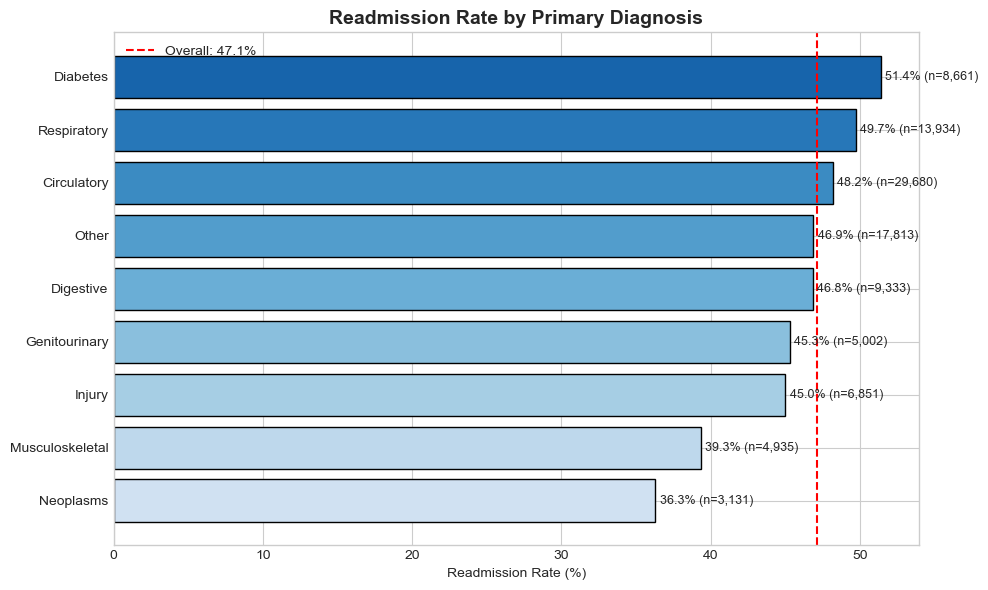

In [24]:
#4.4 Readmission by Primary Diagnosis Group
diag_readmit = df_clean.groupby('diag_1_group')['readmitted_binary'].agg(['mean','count']).reset_index()
diag_readmit.columns = ['category','rate','count']
diag_readmit['rate'] = diag_readmit['rate'] * 100
diag_readmit = diag_readmit.sort_values('rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.2, 0.8, len(diag_readmit)))
ax.barh(diag_readmit['category'].astype(str), diag_readmit['rate'], color=colors, edgecolor='black')
ax.set_xlabel('Readmission Rate (%)')
ax.set_title('Readmission Rate by Primary Diagnosis', fontsize=14, fontweight='bold')
ax.axvline(x=df_clean['readmitted_binary'].mean()*100, color='red', linestyle='--',
           label=f'Overall: {df_clean["readmitted_binary"].mean()*100:.1f}%')
ax.legend()
for i, (_, row) in enumerate(diag_readmit.iterrows()):
    ax.text(row['rate']+0.3, i, f"{row['rate']:.1f}% (n={row['count']:,.0f})", va='center', fontsize=9)
plt.tight_layout()
plt.show()

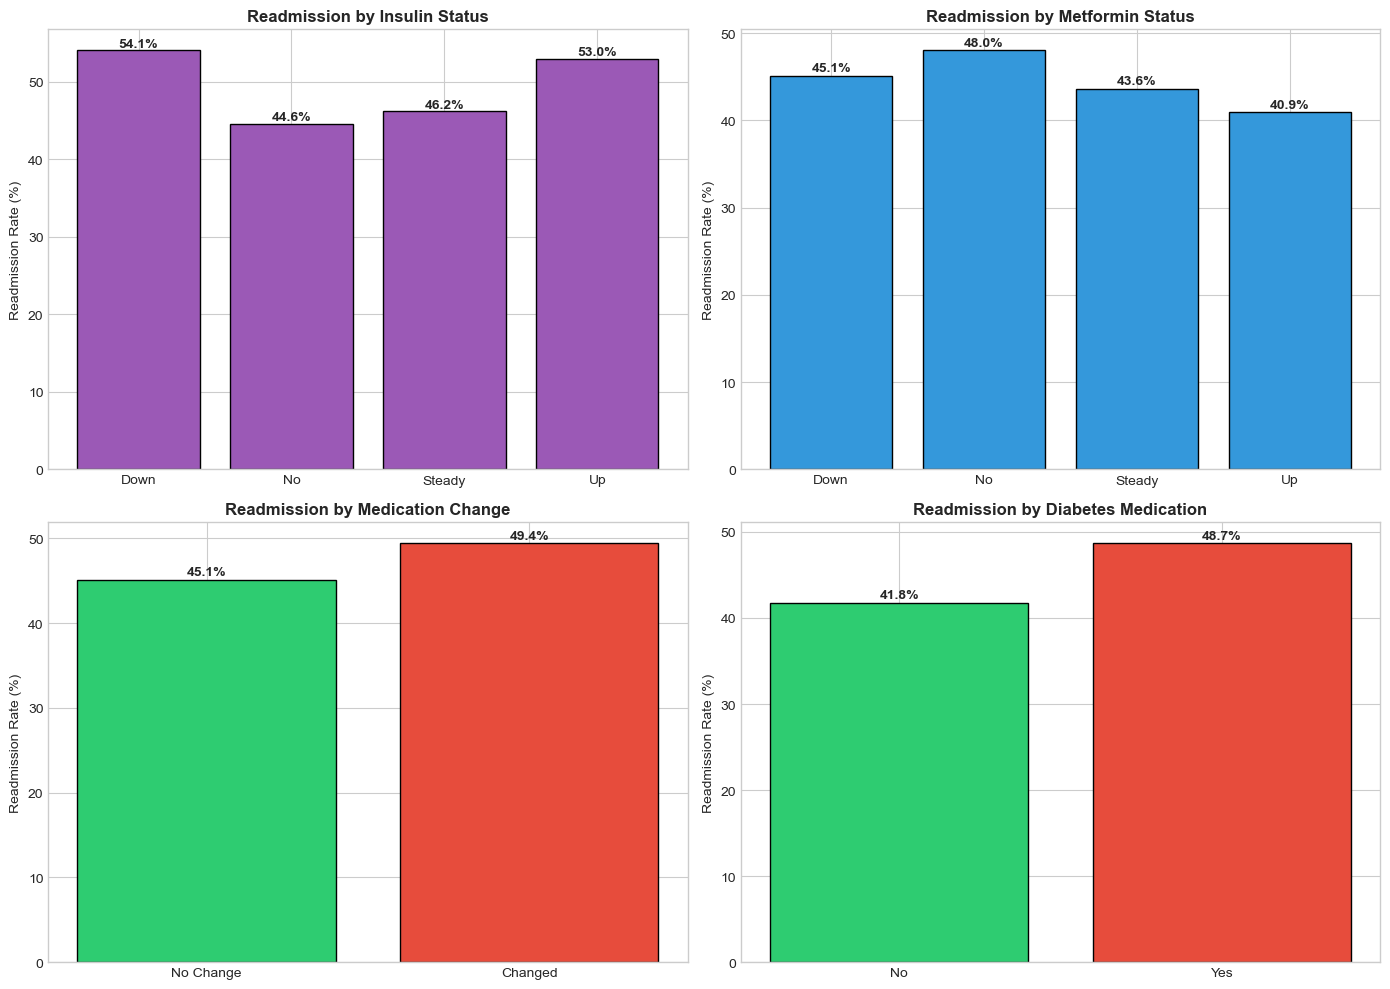

In [25]:
# 4.5 Readmission by Medication Variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Insulin
insulin_readmit = df_clean.groupby('insulin')['readmitted_binary'].mean() * 100
axes[0, 0].bar(insulin_readmit.index.astype(str), insulin_readmit.values, color='#9b59b6', edgecolor='black')
axes[0, 0].set_title('Readmission by Insulin Status', fontweight='bold')
axes[0, 0].set_ylabel('Readmission Rate (%)')
for i, val in enumerate(insulin_readmit.values):
    axes[0, 0].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

# Metformin
metformin_readmit = df_clean.groupby('metformin')['readmitted_binary'].mean() * 100
axes[0, 1].bar(metformin_readmit.index.astype(str), metformin_readmit.values, color='#3498db', edgecolor='black')
axes[0, 1].set_title('Readmission by Metformin Status', fontweight='bold')
axes[0, 1].set_ylabel('Readmission Rate (%)')
for i, val in enumerate(metformin_readmit.values):
    axes[0, 1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

# Medication Changed
change_labels = {0: 'No Change', 1: 'Changed'}
change_readmit = df_clean.groupby('change')['readmitted_binary'].mean() * 100
change_readmit.index = change_readmit.index.map(change_labels)
axes[1, 0].bar(change_readmit.index, change_readmit.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1, 0].set_title('Readmission by Medication Change', fontweight='bold')
axes[1, 0].set_ylabel('Readmission Rate (%)')
for i, val in enumerate(change_readmit.values):
    axes[1, 0].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

# Diabetes Medication
diabmed_labels = {0: 'No', 1: 'Yes'}
diabmed_readmit = df_clean.groupby('diabetesMed')['readmitted_binary'].mean() * 100
diabmed_readmit.index = diabmed_readmit.index.map(diabmed_labels)
axes[1, 1].bar(diabmed_readmit.index, diabmed_readmit.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1, 1].set_title('Readmission by Diabetes Medication', fontweight='bold')
axes[1, 1].set_ylabel('Readmission Rate (%)')
for i, val in enumerate(diabmed_readmit.values):
    axes[1, 1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

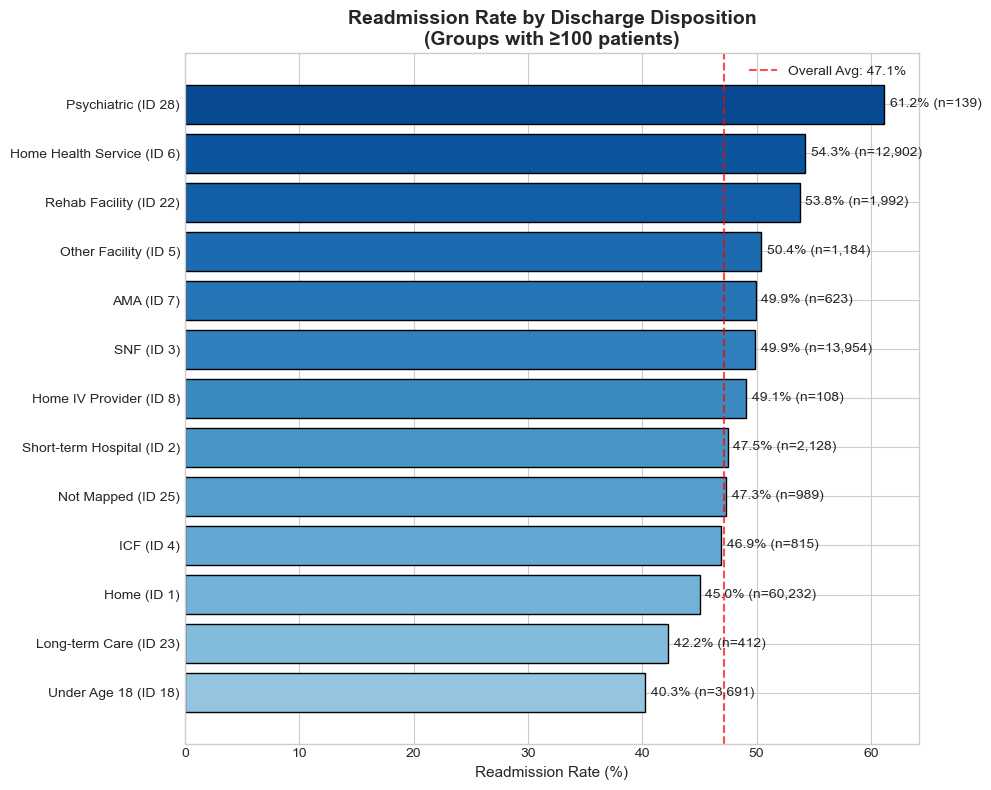

In [26]:
# 4.6 Readmission by Discharge Disposition
discharge_labels = {
    1: 'Home', 2: 'Short-term Hospital', 3: 'SNF', 4: 'ICF',
    5: 'Other Facility', 6: 'Home Health Service', 7: 'AMA',
    8: 'Home IV Provider', 9: 'Admitted as Inpatient', 10: 'Neonate',
    12: 'Still Patient', 15: 'Swing Bed', 16: 'Swing Bed (Short-term)',
    17: 'Swing Bed (Short-term)', 18: 'Under Age 18',
    22: 'Rehab Facility', 23: 'Long-term Care', 24: 'Medicaid Certified',
    25: 'Not Mapped', 26: 'Unknown', 27: 'Federal Hospital', 28: 'Psychiatric',
    29: 'Critical Access', 30: 'Another Facility'
}

# 2. Process data
disch_stats = df_clean.groupby('discharge_disposition_id').agg(
    count=('readmitted_binary', 'size'),
    readmit_rate=('readmitted_binary', 'mean')
).reset_index()

disch_stats['readmit_rate'] = disch_stats['readmit_rate'] * 100
disch_stats['label'] = disch_stats['discharge_disposition_id'].map(discharge_labels).fillna('Other')
disch_stats['display'] = disch_stats['label'] + ' (ID ' + disch_stats['discharge_disposition_id'].astype(str) + ')'

# Filter for significance (at least 100 patients)
disch_plot = disch_stats[disch_stats['count'] >= 100].sort_values('readmit_rate', ascending=True)

plt.figure(figsize=(10, 8))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(disch_plot))) # Slightly darker blues for readability

plt.barh(disch_plot['display'], disch_plot['readmit_rate'], color=colors, edgecolor='black')

# Add the baseline mean line
overall_mean = df_clean['readmitted_binary'].mean() * 100
plt.axvline(x=overall_mean, color='red', linestyle='--', alpha=0.7,
            label=f'Overall Avg: {overall_mean:.1f}%')

# Labels
plt.xlabel('Readmission Rate (%)', fontsize=11)
plt.title('Readmission Rate by Discharge Disposition\n(Groups with ≥100 patients)', fontsize=14, fontweight='bold')
plt.legend()

# Value labels
for i, (_, row) in enumerate(disch_plot.iterrows()):
    plt.text(row['readmit_rate'] + 0.5, i, f"{row['readmit_rate']:.1f}% (n={row['count']:,})",
             va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 5. Prepare Model

In [27]:
# Prepare feature sets
# LightGBM uses native categorical handling
# LogReg and RF need one-hot encoded dummies

X = df_clean.drop(columns=['readmitted_binary'])
y = df_clean['readmitted_binary']

# Identify categorical columns for LightGBM
cat_cols = X.select_dtypes(include='category').columns.tolist()
print(f"Categorical features for LightGBM: {cat_cols}")
print(f"Total features (LightGBM): {X.shape[1]}, Instances: {X.shape[0]:,}")

# Create one-hot encoded version for LogReg and RF
X_dummies = pd.get_dummies(X, columns=cat_cols, drop_first=False)
print(f"Total features (LogReg/RF after dummies): {X_dummies.shape[1]}")

Categorical features for LightGBM: ['race', 'gender', 'payer_code', 'medical_specialty', 'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'diag_1_group', 'diag_2_group', 'diag_3_group']
Total features (LightGBM): 28, Instances: 99,340
Total features (LogReg/RF after dummies): 88


In [28]:
# Train-test split: same indices for both feature sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_dum, X_test_dum = X_dummies.loc[X_train.index], X_dummies.loc[X_test.index]

print(f"Training: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Train positive rate: {y_train.mean()*100:.1f}% | Test positive rate: {y_test.mean()*100:.1f}%")

Training: 79,472 | Test: 19,868
Train positive rate: 47.1% | Test positive rate: 47.1%


In [29]:
# Scale the dummy features for Logistic Regression to manage outliers
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_dum)
X_test_scaled = scaler.transform(X_test_dum)

---
## 6. Model Training: Algorithm Comparison

Train all three algorithms on the full feature set and compare.

In [45]:
# Baseline
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_dum, y_train)
y_pred_dummy = dummy.predict(X_test_dum)
y_prob_dummy = dummy.predict_proba(X_test_dum)[:, 1]
# Calculate Metrics
metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_dummy),
    'Precision': precision_score(y_test, y_pred_dummy, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_dummy, zero_division=0),
    'F1-Score':  f1_score(y_test, y_pred_dummy, zero_division=0),
    'AUC-ROC':   roc_auc_score(y_test, y_prob_dummy)
}
print
for name, value in metrics.items():
    print(f"  {name:10}: {value:.4f}")

  Accuracy  : 0.5287
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000
  AUC-ROC   : 0.5000


In [33]:
# 6.1 Logistic Regression (uses one-hot encoded features). We use 1000 iterations because the dataset is large, we need for iterations to actually get to the result.
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"Logistic Regression stats (using {X_train_dum.shape[1]} one-hot features)")
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_lr):.4f}")

Logistic Regression stats (using 88 one-hot features)

Accuracy:  0.6236
Precision: 0.6381
Recall:    0.4649
F1-Score:  0.5379
AUC-ROC:   0.6691


In [34]:
# 6.2 Random Forest (uses one-hot encoded features, unscaled)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=20,
                                   min_samples_leaf=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_dum, y_train)
y_pred_rf = rf_model.predict(X_test_dum)
y_prob_rf = rf_model.predict_proba(X_test_dum)[:, 1]

print(f"Random Forest stats (using {X_train_dum.shape[1]} one-hot features)")
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_rf):.4f}")

Random Forest stats (using 88 one-hot features)

Accuracy:  0.6356
Precision: 0.6491
Recall:    0.4936
F1-Score:  0.5608
AUC-ROC:   0.6848


In [35]:
# 6.3 LightGBM
# We used 500 estimators as a balanced starting point that is less likely to over/under fit than something like 50 or
# 1000. We used a low learning rate of 0.02 for better precision, higher values like 0.1 would risk overfitting for a dataset this large.

lgbm_model = LGBMClassifier(
    n_estimators=500,     # more trees to benefit from lower learning rate
    learning_rate=0.02,
    max_depth=-1,
    num_leaves=64,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(
    X_train, y_train,
    categorical_feature=cat_cols
)

y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

print(f"LightGBM stats (using {X_train.shape[1]} features with {len(cat_cols)} native categoricals)")
print(f"  Hyperparams: num_leaves=64, learning_rate=0.02, n_estimators=500")
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lgbm):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lgbm):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lgbm):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_lgbm):.4f}")

cv_scores = cross_val_score(lgbm_model, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
print(f"\n5-Fold CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

LightGBM stats (using 28 features with 14 native categoricals)
  Hyperparams: num_leaves=64, learning_rate=0.02, n_estimators=500

Accuracy:  0.6415
Precision: 0.6360
Recall:    0.5594
F1-Score:  0.5953
AUC-ROC:   0.6920

5-Fold CV AUC: 0.6748 (+/- 0.0178)



5-Fold CV AUC: 0.6749 (+/- 0.0179)


In [36]:
results = {}
for name, (pred, prob) in {
    "LogReg": (y_pred_lr, y_prob_lr),
    "RandomForest": (y_pred_rf, y_prob_rf),
    "LightGBM": (y_pred_lgbm, y_prob_lgbm)
}.items():
    results[name] = [
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob)
    ]

model_metrics = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1", "AUC"])
model_metrics

,LogReg,RandomForest,LightGBM
Accuracy,0.623566,0.635595,0.641484
Precision,0.638083,0.649066,0.635988
Recall,0.464915,0.493645,0.559436
F1,0.537905,0.560786,0.595261
AUC,0.669102,0.684830,0.692009


<h4>LightGBM has the highest AUC score (Best probability of correctly identifying high-risk patients) by a small margin, but it has the best Recall (Caught the best percentage of high-risk patients across the whole datasets) by quite a significant amount. The other 2 models have a recall below 50%.</h4>

<h4>As seen earlier, LightGBM captured the most number of actual readmissions. It captures the highest amount of False Positives (Not actually Readmitted, but for a Clinical purpose, it is better to be safe than sorry as the cost of missing out actual readmissions is much higher than any support packages for potential readmissions.</h4>

---
## 7. Feature Importance Analysis

In [38]:
# LightGBM Feature Importance
lgbm_importance = pd.DataFrame({'feature':X.columns,'importance':lgbm_model.feature_importances_}).sort_values('importance',ascending=False)

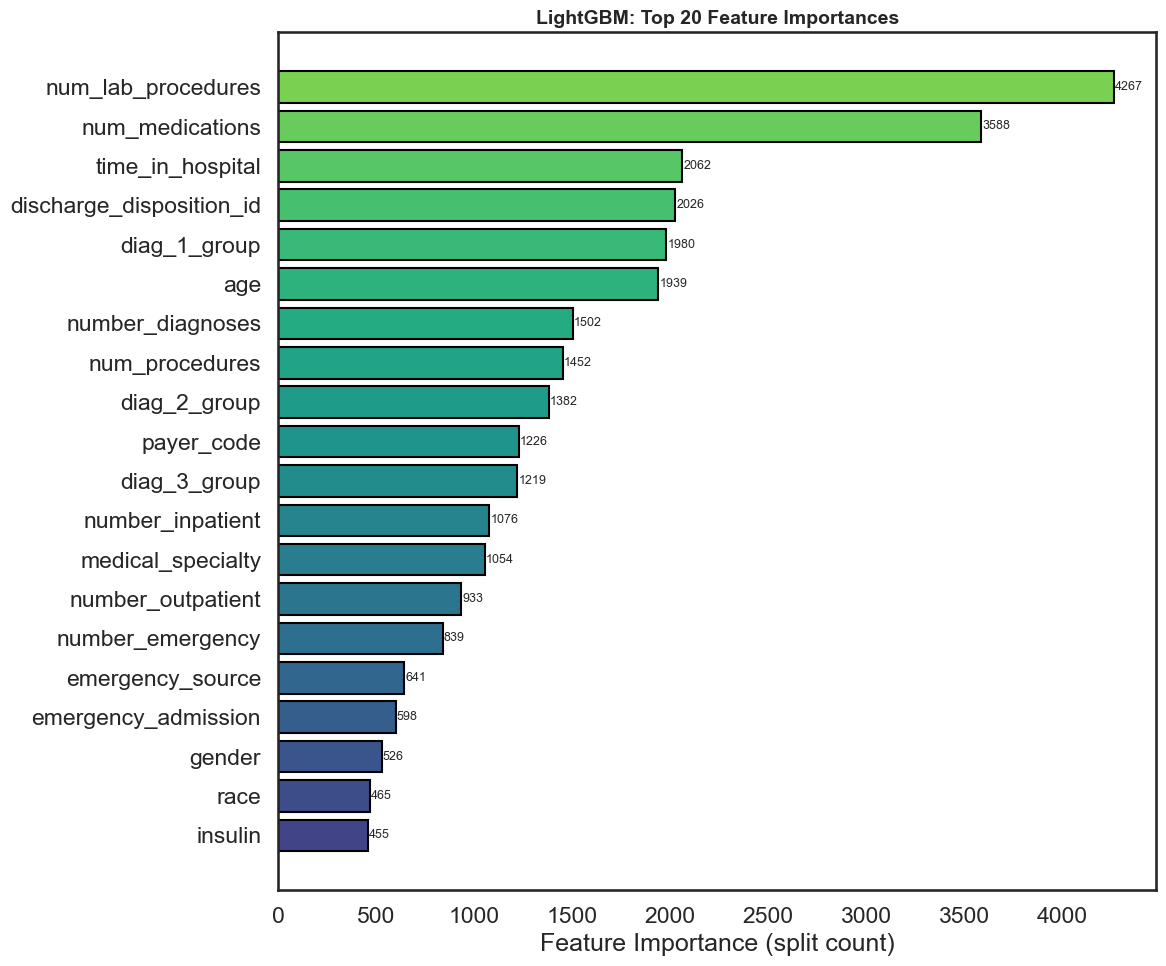

In [39]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(12, 10))
top_20 = lgbm_importance.head(20).sort_values('importance')
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_20)))
ax.barh(top_20['feature'], top_20['importance'], color=colors, edgecolor='black')
ax.set_xlabel('Feature Importance (split count)')
ax.set_title('LightGBM: Top 20 Feature Importances', fontsize=14, fontweight='bold')
for i, (_, row) in enumerate(top_20.iterrows()):
    ax.text(row['importance']+5, i, f"{row['importance']:.0f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

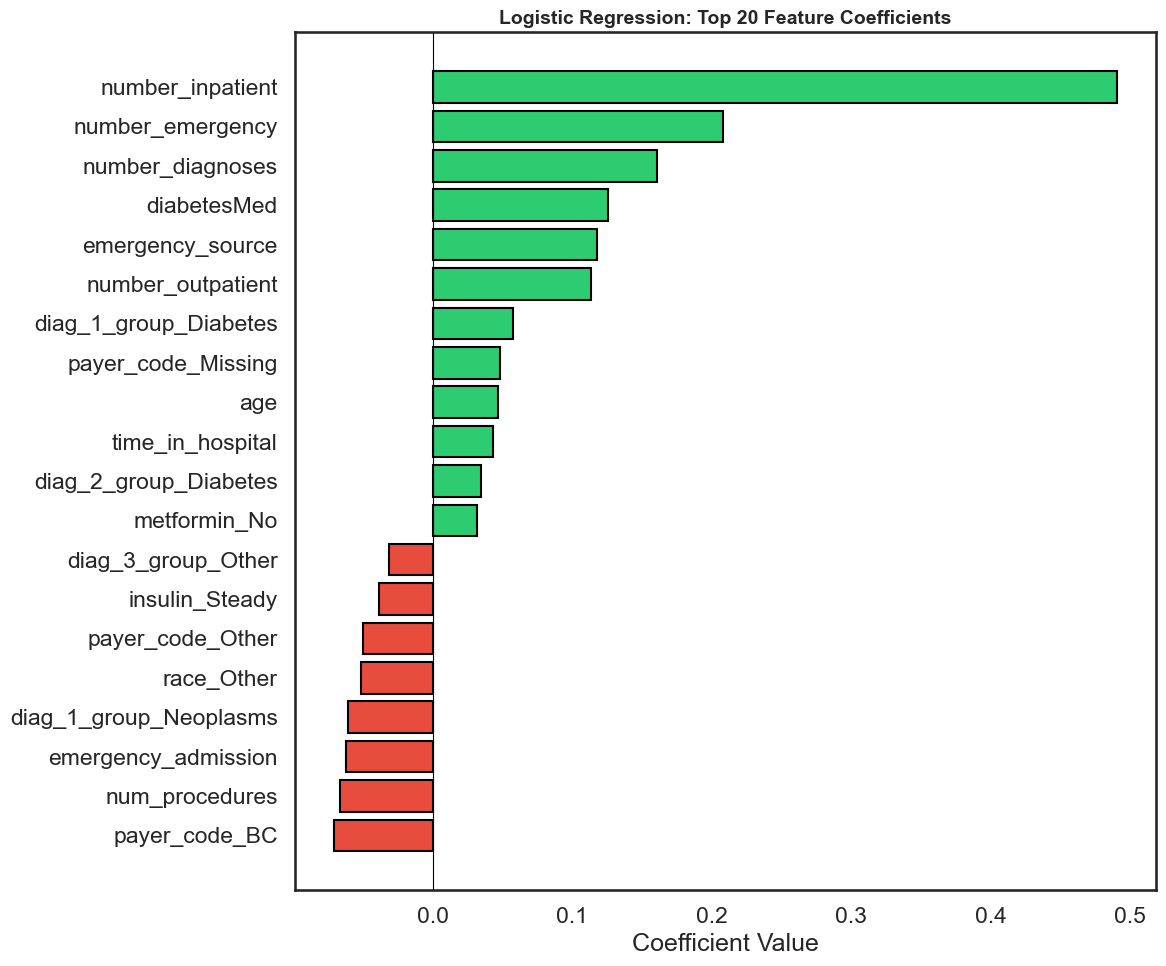

In [40]:
# Logistic Regression Coefficients (uses one-hot encoded features)
lr_importance = pd.DataFrame({'feature':X_dummies.columns,'coefficient':lr_model.coef_[0]}).sort_values('coefficient',key=abs,ascending=False)
fig, ax = plt.subplots(figsize=(12, 10))
top_20_lr = lr_importance.head(20).sort_values('coefficient')
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in top_20_lr['coefficient']]
ax.barh(top_20_lr['feature'], top_20_lr['coefficient'], color=colors, edgecolor='black')
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression: Top 20 Feature Coefficients', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

---
## 8. Exporting Predictive Model for Tableau


In [41]:
# Score the full dataset using LightGBM
df_scored = df_clean.copy()

df_scored["readmit_probability"] = lgbm_model.predict_proba(X)[:, 1]
df_scored["predicted_readmit"] = (df_scored["readmit_probability"] >= 0.5).astype(int)

# Select columns for Tableau dashboard
cols_to_export = [
    # Predictions
    "predicted_readmit",
    "readmit_probability",
    "readmitted_binary",

    # Demographics
    "age",
    "gender",
    "race",

    # Hospital stay
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_inpatient",
    "number_emergency",
    "number_outpatient",

    # Medical management
    "change",
    "diabetesMed",
    "insulin",
    "metformin",

    # Admission/discharge
    "discharge_disposition_id",
    "emergency_admission",
    "emergency_source",

    # Diagnosis groups
    "diag_1_group",
    "diag_2_group",
    "diag_3_group",

    # Other categoricals
    "medical_specialty",
    "payer_code",
]

# Filter to only include columns that actually exist
cols_to_export = [c for c in cols_to_export if c in df_scored.columns]

# Export to CSV (category dtype exports as readable strings)
df_scored[cols_to_export].to_csv("Readmissions_predictions_capstone.csv", index=False)

print(f"Exported: readmission_predictions.csv")
print(f"- Rows: {len(df_scored):,}")
print(f"- Columns: {len(cols_to_export)}")
print(f"\nColumns included:")

Exported: readmission_predictions.csv
- Rows: 99,340
- Columns: 24

Columns included:
